# Housing Prices: Categorical Encoding and Prediction Pipeline
**Author:** Bridget  
**Course:** DAS
***




## Step One: Library Imports and Data Load

We import our core libraries and separate the target variable (`SalePrice`) 
from the features.


In [53]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

X_train_raw = df_train.drop(columns=['Id', 'SalePrice'])
y_train = df_train['SalePrice']
X_test_raw = df_test.drop(columns=['Id'])

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


## Step Two: Target Variable Distribution Check

We plot a histogram of our target variable `SalePrice` to inspect the 
distribution of house prices and check for anomalies across the training 
dataset.


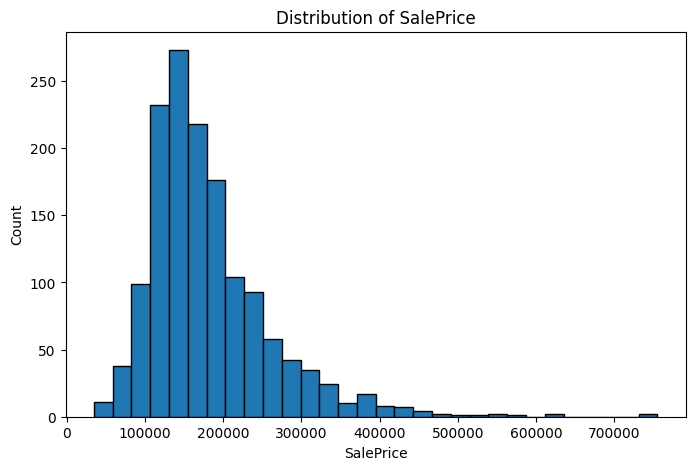

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_train['SalePrice'].hist(bins=30, edgecolor='black', grid=False)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()


## Step Three: Fix MSSubClass's Data Type

`MSSubClass` is stored as an integer (20, 60, 70...), but these numbers are 
building-class codes, not a quantity.A value of 60 is not "more" than 20. 
Left as a number, a regression model would wrongly assume a numeric 
relationship between classes. We convert it to a string so it's treated as 
categorical.

In [55]:
X_train_raw['MSSubClass'] = X_train_raw['MSSubClass'].astype(str)
X_test_raw['MSSubClass'] = X_test_raw['MSSubClass'].astype(str)

categorical_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train_raw.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")


Categorical features: 44
Numeric features: 35


## Step Four: Handle Missing Values

Before filling anything blindly, we separate two different situations:

1. **NaN means the feature doesn't exist**.For columns like `PoolQC` or 
   `GarageType`, a missing value means the house has no pool or no garage, 
   not that data is missing. These get filled with `'None'` as a real 
   category.
2. **NaN means data is genuinely missing**.For columns like `LotFrontage` 
   or `Electrical`, we impute with a sensible statistic (median/mode) rather 
   than treating the absence as its own category.


In [56]:
X_train_clean = X_train_raw.copy()
X_test_clean = X_test_raw.copy()

na_means_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in na_means_none:
    X_train_clean[col] = X_train_clean[col].fillna('None')
    X_test_clean[col] = X_test_clean[col].fillna('None')

X_train_clean['LotFrontage'] = X_train_clean.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
X_test_clean['LotFrontage'] = X_test_clean['LotFrontage'].fillna(X_train_clean['LotFrontage'].median())

X_train_clean['MasVnrArea'] = X_train_clean['MasVnrArea'].fillna(0)
X_test_clean['MasVnrArea'] = X_test_clean['MasVnrArea'].fillna(0)

X_train_clean['Electrical'] = X_train_clean['Electrical'].fillna(X_train_clean['Electrical'].mode()[0])
X_test_clean['Electrical'] = X_test_clean['Electrical'].fillna(X_train_clean['Electrical'].mode()[0])

X_train_clean['GarageYrBlt'] = X_train_clean['GarageYrBlt'].fillna(0)
X_test_clean['GarageYrBlt'] = X_test_clean['GarageYrBlt'].fillna(0)

for col in numeric_cols:
    if X_train_clean[col].isna().sum() > 0 or X_test_clean[col].isna().sum() > 0:
        median_val = X_train_clean[col].median()
        X_train_clean[col] = X_train_clean[col].fillna(median_val)
        X_test_clean[col] = X_test_clean[col].fillna(median_val)

for col in categorical_cols:
    if X_train_clean[col].isna().sum() > 0 or X_test_clean[col].isna().sum() > 0:
        mode_val = X_train_clean[col].mode()[0]
        X_train_clean[col] = X_train_clean[col].fillna(mode_val)
        X_test_clean[col] = X_test_clean[col].fillna(mode_val)

print("Remaining NaNs in train:", X_train_clean.isna().sum().sum())
print("Remaining NaNs in test:", X_test_clean.isna().sum().sum())



Remaining NaNs in train: 0
Remaining NaNs in test: 0


## Step Five: Define Ridge Regression Evaluation Function

A reusable helper that splits the data, fits a Ridge regression model, and 
reports validation R².


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def evaluate_model(X, y):
    X_train, X_val, y_train_, y_val = train_test_split(X, y, random_state=42, test_size=0.2)
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train_)
    preds = model.predict(X_val)
    score = r2_score(y_val, preds)
    print(f"Validation R^2 Score: {score:.4f}")
    return score




## Step Six: Ordinal Encoding for Ranked Quality Columns

Several categorical columns have a genuine order,for example `ExterQual` 
goes from Poor to Excellent. Assigning these integers 0, 1, 2... in rank 
order preserves that meaning.

We map each ranked column by hand, using the category definitions from the 
data dictionary.


In [58]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
pool_map = {'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}

ordinal_maps = {
    'ExterQual': qual_map,
    'ExterCond': qual_map,
    'BsmtQual': qual_map,
    'BsmtCond': qual_map,
    'HeatingQC': qual_map,
    'KitchenQual': qual_map,
    'FireplaceQu': qual_map,
    'GarageQual': qual_map,
    'GarageCond': qual_map,
    'PoolQC': pool_map,
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Functional': {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7},
    'LandSlope': {'Sev': 0, 'Mod': 1, 'Gtl': 2},
    'LotShape': {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'Utilities': {'ELO': 0, 'NoSeWa': 1, 'NoSewr': 2, 'AllPub': 3},
}


for col, mapping in ordinal_maps.items():
    X_train_clean[col] = X_train_clean[col].map(mapping)
    X_test_clean[col] = X_test_clean[col].map(mapping)
    fallback = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(fallback)
    X_test_clean[col] = X_test_clean[col].fillna(fallback)

print(f"Ordinal-encoded columns: {len(ordinal_maps)}")
evaluate_model(pd.concat([X_train_clean[numeric_cols], X_train_clean[list(ordinal_maps.keys())]], axis=1), y_train)



Ordinal-encoded columns: 19
Validation R^2 Score: 0.8393


0.8393102764296864

## Step Seven: One-Hot Encoding for Nominal Columns

The remaining categorical columns (`Neighborhood`, `MSZoning`, `Foundation`, 
`SaleType`, `MSSubClass`, etc.) have no natural order,there's no sense in 
which one neighborhood is greater than another. Assigning these integers, 
ordinal or arbitrary, would invent a false relationship. One-hot encoding 
avoids that by giving each category its own binary column.


In [59]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = [c for c in categorical_cols if c not in ordinal_maps]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train_clean[nominal_cols])

ohe_train_array = ohe.transform(X_train_clean[nominal_cols])
ohe_test_array = ohe.transform(X_test_clean[nominal_cols])

ohe_train_df = pd.DataFrame(
    ohe_train_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train_clean.index
)
ohe_test_df = pd.DataFrame(
    ohe_test_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_test_clean.index
)

X_train_final = pd.concat([X_train_clean[numeric_cols], X_train_clean[list(ordinal_maps.keys())], ohe_train_df], axis=1)
X_test_final = pd.concat([X_test_clean[numeric_cols], X_test_clean[list(ordinal_maps.keys())], ohe_test_df], axis=1)

print(f"Nominal columns one-hot encoded: {len(nominal_cols)}")
print(f"Final training shape: {X_train_final.shape}")


Nominal columns one-hot encoded: 25
Final training shape: (1460, 243)


## Step Eight: Validate the Full Encoding

We evaluate the combined pipeline;numeric features, ordinal-encoded 
quality columns, and one-hot encoded nominal columns together.

In [60]:
evaluate_model(X_train_final, y_train)


Validation R^2 Score: 0.8778


0.8777669323890248

## Step Nine: Generate Final Test Predictions

We fit the final Ridge model on the full training set using our combined 
ordinal + one-hot encoding, then predict on the test set and build the 
submission file.

In [61]:
final_model = Ridge(alpha=1.0)
final_model.fit(X_train_final, y_train)
final_predictions = final_model.predict(X_test_final)

submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': final_predictions
})
submission.to_csv('my_submission.csv', index=False)
submission.head()


,Id,SalePrice
0,1461,110712.369263
1,1462,154508.552426
2,1463,171032.822333
3,1464,177743.515982
4,1465,223265.118255


## Summary of Findings

I matched the encoding technique to what each variable actually represents, 
rather than applying one method across every categorical column:

- **Ordinal encoding** for columns with a genuine rank (e.g. quality ratings 
  from Poor to Excellent), so the model can use the order between categories.
- **One-hot encoding** for columns with no natural order (e.g. Neighborhood, 
  SaleType), so no false ranking is introduced.


The combined pipeline scored a validation R² of **0.8778**, close to the 
one-hot-only baseline but with encodings that reflect the actual structure 
of each variable rather than just the score they happen to produce.

Two decisions mattered most for correctness rather than performance:

- **`MSSubClass`** looks numeric but its values (20, 60, 70...) are building-
  class codes, not quantities. Left as an integer, the model would treat 
  60 as "more" than 20, which has no real meaning.Converting it to a 
  string before encoding was necessary regardless of what it did to the score.
- **Distinguishing "no feature" from "missing data"** in the NaN handling 
  meant checking each column's meaning individually (e.g. against the data 
  dictionary) rather than filling every blank the same way. Columns like 
  `PoolQC` or `GarageType` use NaN to mean the house doesn't have that 
  feature, while columns like `LotFrontage` or `Electrical` use NaN to mean 
  the value wasn't recorded,those needed different treatment (a real 
  `'None'` category vs. a statistical imputation).

Overall, this reflects encoding as a modeling decision grounded in what each 
column represents, not a search over methods for whichever produces the 
highest validation score.
